# Lab: Simple Linear Regression
*In this lab, we will build a Simple Linear Regression model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow.*

---

## Stage 1: Business Understanding
This project simulates a common business problem for a hypothetical company, "AdSmart." The company allocates its budget across TV, Radio, and Newspaper advertising but lacks a data-driven way to understand the impact of this spending on sales.

*   **Business Problem:** The marketing team cannot confidently predict how changes in advertising spend will affect sales, making budget allocation inefficient and based on intuition rather than evidence.
*   **Project Goal:** To build a predictive model that quantifies the relationship between advertising spend and sales. This initial lab will focus on creating a simple model to analyze the impact of **TV advertising** on **Sales**, proving the concept and providing an initial actionable insight.

---

## Stage 2: Analytic Approach
To address the business problem, we are framing this as a supervised machine learning task.

*   **Problem Type:** **Supervised Regression**, as the goal is to predict a continuous numerical value (Sales).
*   **Model Selection:** We will use **Simple Linear Regression** as our baseline model. Its simplicity and high interpretability are ideal for establishing the fundamental relationship between a single feature (TV ad spend) and the target (Sales).
*   **Evaluation Metrics:**
    *   **R-squared:** To measure how much of the variability in sales our model can explain.
    *   **Regression Coefficient:** To provide a direct, actionable insight into how each dollar spent on TV advertising impacts sales units.

---

## Stage 3: Data Requirements

The analytic approach requires a dataset containing advertising budgets and corresponding sales figures.

*   **Data Source:** We are using the `advertising.csv` dataset, which contains data from 200 different markets.
*   **Key Fields:**
    *   **Feature (Independent Variable):** `TV` (spend in thousands of dollars).
    *   **Target (Dependent Variable):** `Sales` (in thousands of units).
*   **Granularity & Privacy:** Each row represents an individual market. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection
The dataset has been provided by the business owner and saved to `./data/advertising.csv`.

Let's import the necessary libraries, load the dataset, and perform a quick, high-level check to ensure it is readable and appears correct.

In [213]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)

In [214]:
# Load the data (TV and Sales columns only)
data = pd.read_csv("./data/advertising.csv")

# Take a look at the first 5 rows
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [215]:
# Display general information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


> #### 📝 Data Collection Report
> * The data was successfully loaded from `./data/advertising.csv`.
> * The number of rows matches the expected count of 200 markets.
> * The `Unnamed: 0` column appears to be an index and can be dropped. The other columns (`TV`, `Radio`, `Newspaper`, `Sales`) are present as expected.

---

## Stage 5: Data Understanding

The goal of this stage is to conduct Exploratory Data Analysis (EDA) to develop a deep understanding of the data's content, quality, and structure. Through descriptive statistics and visualization, we aim to uncover initial patterns, spot anomalies or data quality issues, and validate (or challenge) the initial hypotheses formed during the business understanding phase.

### 5.1. Initial Data Shaping

Before diving into analysis, let's perform a first pass of cleaning and shaping. This is not the exhaustive cleaning that will happen in Stage 6, but rather a set of preliminary steps to make the data usable for EDA. The goal is to handle obvious errors and inconsistencies that would otherwise break visualizations or skew summary statistics.

In [216]:
# Drop columns we know we won't be using
columns_to_drop = ['Unnamed: 0', 'Radio', 'Newspaper']
sales_df = data.drop(columns=columns_to_drop)

# Convert column names to lower case
sales_df.columns = [col.lower() for col in sales_df.columns]

# Check the number of duplicated rows
print(f"There are {sales_df.duplicated().sum()} duplicated rows in the dataset.")

There are 0 duplicated rows in the dataset.


In [217]:
# Check the data types of the columns
print(sales_df.dtypes)

tv       float64
sales    float64
dtype: object


> #### 📝 Initial Data Shaping Report
> * Unneeded columns are dropped, the column names are converted to lower case, and no duplicated rows are spotted in the dataset.
> * `sales_df` is ready for Exploratory Data Analysis.

### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

In [218]:
sales_df.describe().T

,count,mean,std,min,25%,50%,75%,max
tv,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


> #### 📝 Descriptive Statistics Report
> *   **TV Advertising (`tv`):** The mean *($147,042)* and the median *($149,750)* are very close, while the standard deviation is high at *($85,854)*. This indicates a **wide and roughly symmetrical distribution** of advertising spend.
> *   **Sales (`sales`):** The mean *(14,023 units)* is slightly higher than the median *(12,900 units)*. This suggests a **slight right skew** in the sales data, where a few markets with exceptionally high sales pull the average up.
> *   **Conclusion:** Both the independent variable (`tv`) and the dependent variable (`sales`) have a good range of values. The wide distribution in TV ad spending is especially beneficial for a regression analysis, as it provides diverse data points from which the model can effectively learn the underlying relationship.

### Univariate Analysis
Now, let's analyze individual variables to understand their own distributions and characteristics.

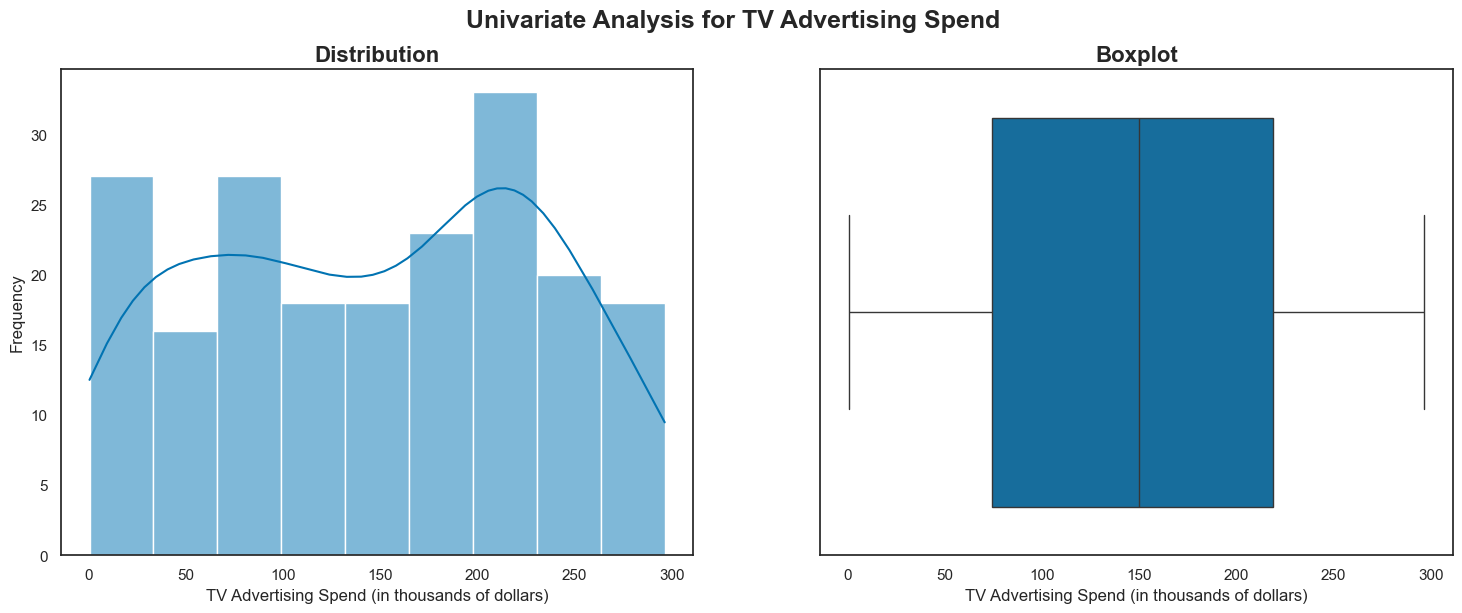

In [254]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for TV Advertising Spend", fontsize=18, fontweight='bold')
# The histogram of TV advertising spend
sns.histplot(sales_df, x="tv", kde=True, ax=ax[0])
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("TV Advertising Spend (in thousands of dollars)")
ax[0].set_ylabel("Frequency")
# The boxplot of TV advertising spend
sns.boxplot(sales_df, x="tv", ax=ax[1])
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("TV Advertising Spend (in thousands of dollars)")     
plt.show()